Requirements

In [ ]:
import os
import json
import cv2
import librosa
import IPython
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from warnings import filterwarnings

filterwarnings(action='ignore')

dataset

In [ ]:
!pip install opendatasets --quiet

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: anonymuskotha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022


100%|██████████| 2.06G/2.06G [00:28<00:00, 76.8MB/s]


In [ ]:
import os

dataset_path = "sound-of-114-species-of-birds-till-2022"
os.listdir(dataset_path)


['Birds Voice.csv', 'Voice of Birds']

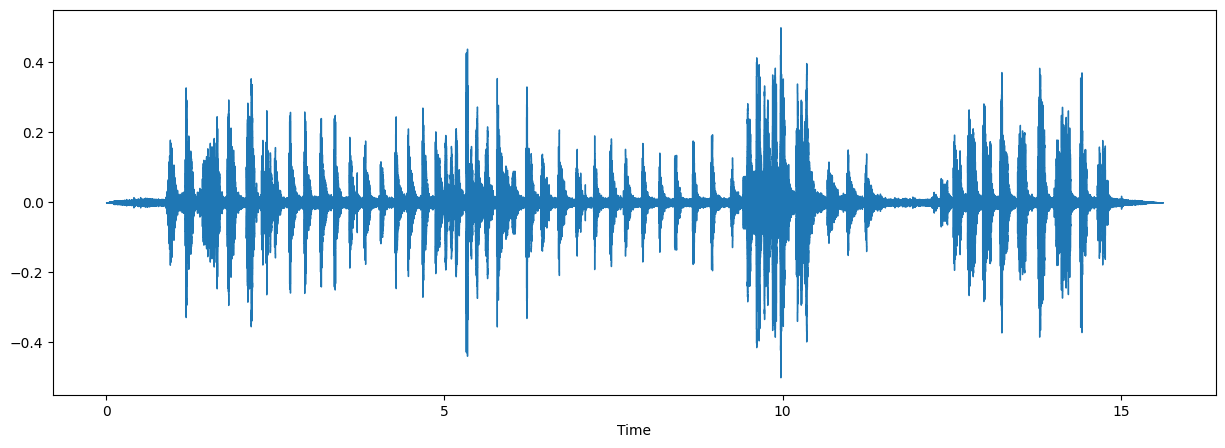

In [ ]:
# Sample Audio Checking


plt.figure(figsize=(15,5))


audio_data, sample_rate = librosa.load(path='/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan12.mp3')
librosa.display.waveshow(y=audio_data, sr=sample_rate)


IPython.display.Audio(data='/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan12.mp3')

In [ ]:

audio_data

array([ 8.6401997e-12, -1.2732926e-11, -1.8189894e-12, ...,
        2.2737368e-13,  3.9790393e-13, -8.5265128e-14], dtype=float32)

In [ ]:

sample_rate

22050

In [ ]:
#Mel-Frequency Cepstral Coefficients
mfccs_features = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)

In [ ]:

mfccs_features, mfccs_features.shape

(array([[-6.2250494e+02, -6.0999127e+02, -5.7499744e+02, ...,
         -6.2250494e+02, -6.2250494e+02, -6.2250494e+02],
        [ 0.0000000e+00,  1.6979631e+01,  4.1984955e+01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  1.5081112e+01,  2.0330677e+01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+00, -7.2471941e-01,  3.1355095e-01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -9.6145850e-01, -1.4942662e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -1.1581554e+00, -1.6853883e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32),
 (40, 673))

In [ ]:
np.mean(mfccs_features, axis=1)

array([-3.0988000e+02,  1.0401821e+01, -9.0290489e+01, -4.4553432e+01,
       -1.8831221e+01,  7.9951978e+00, -1.9813393e+00, -6.6336732e+00,
       -7.9205394e+00,  1.2260886e+01,  1.1192106e+01,  1.1200221e+01,
       -3.1864741e-01,  3.7352815e+00,  5.5541916e+00,  6.4173203e+00,
        4.7119598e+00,  9.6746712e+00, -4.9129989e-02,  4.7118936e+00,
        3.7892053e+00,  8.2409830e+00,  1.1635534e+00,  4.1349072e+00,
        9.1222864e-01,  2.1938601e+00, -1.7673429e+00,  3.5073228e+00,
       -4.5820779e-01,  2.3610861e+00, -5.3835887e-01,  2.1143436e+00,
       -2.3396831e+00,  2.3190188e+00, -1.8095652e+00,  1.0630901e+00,
       -2.8051739e+00, -1.6753919e-01, -1.6882219e+00,  1.8219043e+00],
      dtype=float32)

In [ ]:
np.mean(mfccs_features, axis=1).shape

(40,)

In [ ]:
# Convert the mp3 Audio into Tensors

def audio_to_tensors(audio_file):

    audio, sample_rate =librosa.load(audio_file)


    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_features = np.mean(mfccs_features, axis=1)


    mfccs_tensors = tf.convert_to_tensor(mfccs_features, dtype=tf.float32)

    return mfccs_tensors

In [ ]:
# Sample Audio
audio_sample = '/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan10.mp3'
audio_to_tensors(audio_sample)

<tf.Tensor: shape=(40,), dtype=float32, numpy=
array([-302.7308    ,   70.47813   ,   13.989463  ,   28.275862  ,
          9.768283  ,    7.4185357 ,    3.6636062 ,   12.622561  ,
          0.9152409 ,    3.1517699 ,    4.532145  ,    6.7180843 ,
         -2.0768957 ,    5.589432  ,    3.097847  ,    1.8796207 ,
         -0.49634987,    6.4944406 ,    2.0897276 ,    4.1464815 ,
          2.3515277 ,    7.5341434 ,    0.6378776 ,    5.8427997 ,
          4.5193014 ,    5.5878024 ,    1.6145757 ,    6.6874557 ,
          2.1035838 ,    4.21776   ,    2.5508912 ,    4.6314435 ,
          0.40562916,    4.0922813 ,    1.5406471 ,    3.7211802 ,
          0.51732594,    3.6272905 ,    0.5613322 ,    3.1007853 ],
      dtype=float32)>

In [ ]:
# Extract the Features from Audio Files


directory = '/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds'

extracted_features = []


total_files = sum(len(files) for _, _, files in os.walk(directory))


with tqdm(total=total_files, desc='Processing files') as pbar:

  for target_class in os.listdir(directory):

      target_class_path = os.path.join(directory, target_class)

      for audio_file in os.listdir(target_class_path):

          audio_path = os.path.join(directory, target_class, audio_file)

          features = audio_to_tensors(audio_path)

          extracted_features.append([features, target_class])

          pbar.update(1)

Processing files: 100%|██████████| 2161/2161 [08:35<00:00,  4.19it/s]


In [ ]:
extracted_features[0]

[<tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-2.6162137e+02,  1.0017472e+02, -5.8187084e+01, -3.4613670e+01,
         1.5606578e+01,  3.4925053e-01,  6.9509244e+00,  1.6926140e+01,
         1.5439703e+00,  1.4667584e+01,  8.6910810e+00,  1.9611616e+01,
         1.0289143e-01, -6.4322478e-01,  7.7315106e+00,  8.6140556e+00,
         3.5729604e+00,  1.0665167e+01,  6.4980788e+00,  7.0391917e+00,
        -2.0853660e+00,  7.6989551e+00,  3.7877395e+00,  3.0814977e+00,
        -4.6497339e-01,  5.4086227e+00,  3.3017306e+00,  3.3814192e+00,
        -1.2400681e+00,  4.7902255e+00,  7.4393670e-03,  2.8930366e+00,
        -3.3102903e-01,  3.7151849e+00, -7.2363496e-01,  2.4270403e+00,
        -2.4419595e-02,  3.1138422e+00, -1.4415936e-01,  3.0246594e+00],
       dtype=float32)>,
 'Andean Guan_sound']

In [ ]:
# Creating DataFrame from Extracted Features with Class Labels

features_df = pd.DataFrame(extracted_features, columns=['features', 'class'])
features_df

,features,class
0,"(tf.Tensor(-261.62137, shape=(), dtype=float32...",Andean Guan_sound
1,"(tf.Tensor(-201.20418, shape=(), dtype=float32...",Andean Guan_sound
2,"(tf.Tensor(-351.22318, shape=(), dtype=float32...",Andean Guan_sound
3,"(tf.Tensor(-302.28864, shape=(), dtype=float32...",Andean Guan_sound
4,"(tf.Tensor(-204.62335, shape=(), dtype=float32...",Andean Guan_sound
...,...,...
2156,"(tf.Tensor(-117.19493, shape=(), dtype=float32...",Highland Tinamou_sound
2157,"(tf.Tensor(-290.72336, shape=(), dtype=float32...",Highland Tinamou_sound
2158,"(tf.Tensor(-249.98535, shape=(), dtype=float32...",Highland Tinamou_sound
2159,"(tf.Tensor(-249.98535, shape=(), dtype=float32...",Highland Tinamou_sound


In [ ]:
# Encoding Class Labels using LabelEncoder

target_encoding = LabelEncoder().fit_transform(features_df['class'])
target_encoding

array([ 0,  0,  0, ..., 46, 46, 46])

In [ ]:

features_df['target'] = target_encoding.tolist()
features_df

,features,class,target
0,"(tf.Tensor(-261.62137, shape=(), dtype=float32...",Andean Guan_sound,0
1,"(tf.Tensor(-201.20418, shape=(), dtype=float32...",Andean Guan_sound,0
2,"(tf.Tensor(-351.22318, shape=(), dtype=float32...",Andean Guan_sound,0
3,"(tf.Tensor(-302.28864, shape=(), dtype=float32...",Andean Guan_sound,0
4,"(tf.Tensor(-204.62335, shape=(), dtype=float32...",Andean Guan_sound,0
...,...,...,...
2156,"(tf.Tensor(-117.19493, shape=(), dtype=float32...",Highland Tinamou_sound,46
2157,"(tf.Tensor(-290.72336, shape=(), dtype=float32...",Highland Tinamou_sound,46
2158,"(tf.Tensor(-249.98535, shape=(), dtype=float32...",Highland Tinamou_sound,46
2159,"(tf.Tensor(-249.98535, shape=(), dtype=float32...",Highland Tinamou_sound,46


In [ ]:
prediction_dict = features_df.set_index('target')['class'].to_dict()
prediction_dict

{0: 'Andean Guan_sound',
 38: 'Elegant Crested Tinamou_sound',
 20: 'Chaco Chachalaca_sound',
 69: 'Philippine Megapode_sound',
 92: 'Spotted Nothura_sound',
 91: 'Spixs Guan_sound',
 54: 'Maleo_sound',
 62: 'North Island Brown Kiwi_sound',
 4: 'Barred Tinamou_sound',
 52: 'Little Spotted Kiwi_sound',
 10: 'Black Tinamou_sound',
 60: 'New Guinea Scrubfowl_sound',
 100: 'Tongan Megapode_sound',
 105: 'Wattled Brushturkey_sound',
 61: 'Nicobar Megapode_sound',
 75: 'Red-legged Tinamou_sound',
 45: 'Grey-legged Tinamou_sound',
 30: 'Crested Guan_sound',
 19: 'Cauca Guan_sound',
 86: 'Solitary Tinamou_sound',
 35: 'Dwarf Cassowary_sound',
 94: 'Taczanowskis Tinamou_sound',
 27: 'Collared Brushturkey_sound',
 16: 'Brown Tinamou_sound',
 59: 'Moluccan Megapode_sound',
 64: 'Okarito Kiwi_sound',
 102: 'Undulated Tinamou_sound',
 8: 'Berlepschs Tinamou_sound',
 74: 'Red-faced Guan_sound',
 110: 'White-crested Guan_sound',
 90: 'Speckled Chachalaca_sound',
 5: 'Bartletts Tinamou_sound',
 47: 'H

In [ ]:

with open(file='/content/prediction.json', mode='w') as f:
    json.dump(prediction_dict, f)

In [ ]:
with open(file='/content/prediction.json', mode='r') as f:
    prediction_dict = json.load(f)
prediction_dict

{'0': 'Andean Guan_sound',
 '38': 'Elegant Crested Tinamou_sound',
 '20': 'Chaco Chachalaca_sound',
 '69': 'Philippine Megapode_sound',
 '92': 'Spotted Nothura_sound',
 '91': 'Spixs Guan_sound',
 '54': 'Maleo_sound',
 '62': 'North Island Brown Kiwi_sound',
 '4': 'Barred Tinamou_sound',
 '52': 'Little Spotted Kiwi_sound',
 '10': 'Black Tinamou_sound',
 '60': 'New Guinea Scrubfowl_sound',
 '100': 'Tongan Megapode_sound',
 '105': 'Wattled Brushturkey_sound',
 '61': 'Nicobar Megapode_sound',
 '75': 'Red-legged Tinamou_sound',
 '45': 'Grey-legged Tinamou_sound',
 '30': 'Crested Guan_sound',
 '19': 'Cauca Guan_sound',
 '86': 'Solitary Tinamou_sound',
 '35': 'Dwarf Cassowary_sound',
 '94': 'Taczanowskis Tinamou_sound',
 '27': 'Collared Brushturkey_sound',
 '16': 'Brown Tinamou_sound',
 '59': 'Moluccan Megapode_sound',
 '64': 'Okarito Kiwi_sound',
 '102': 'Undulated Tinamou_sound',
 '8': 'Berlepschs Tinamou_sound',
 '74': 'Red-faced Guan_sound',
 '110': 'White-crested Guan_sound',
 '90': 'Spec

In [ ]:
# Converting Features into List
features = features_df['features'].tolist()
features

[<tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-2.6162137e+02,  1.0017472e+02, -5.8187084e+01, -3.4613670e+01,
         1.5606578e+01,  3.4925053e-01,  6.9509244e+00,  1.6926140e+01,
         1.5439703e+00,  1.4667584e+01,  8.6910810e+00,  1.9611616e+01,
         1.0289143e-01, -6.4322478e-01,  7.7315106e+00,  8.6140556e+00,
         3.5729604e+00,  1.0665167e+01,  6.4980788e+00,  7.0391917e+00,
        -2.0853660e+00,  7.6989551e+00,  3.7877395e+00,  3.0814977e+00,
        -4.6497339e-01,  5.4086227e+00,  3.3017306e+00,  3.3814192e+00,
        -1.2400681e+00,  4.7902255e+00,  7.4393670e-03,  2.8930366e+00,
        -3.3102903e-01,  3.7151849e+00, -7.2363496e-01,  2.4270403e+00,
        -2.4419595e-02,  3.1138422e+00, -1.4415936e-01,  3.0246594e+00],
       dtype=float32)>,
 <tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-201.20418   ,   62.074387  ,    4.317729  ,   10.269427  ,
           8.900269  ,   11.321092  ,    3.3744543 ,    4.0346494 ,
           2.6990578 , 

In [ ]:
# Converting Targets into Lists
target = features_df['target'].tolist()
print(target)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 54, 54, 54, 54, 54, 54, 54, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 4, 4, 4, 52, 52, 52, 52, 52, 52, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 105, 105, 105, 61, 61, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75,

In [ ]:
# Converting Features and Targets to TensorFlow Tensors
features_tensor = tf.convert_to_tensor(features)
target_tensor = tf.convert_to_tensor(target)

In [ ]:
features_tensor

<tf.Tensor: shape=(2161, 40), dtype=float32, numpy=
array([[-2.6162137e+02,  1.0017472e+02, -5.8187084e+01, ...,
         3.1138422e+00, -1.4415936e-01,  3.0246594e+00],
       [-2.0120418e+02,  6.2074387e+01,  4.3177290e+00, ...,
         3.9226225e-01, -2.8225689e+00,  2.9005628e+00],
       [-3.5122318e+02,  5.1955341e+01, -3.6098488e+01, ...,
         2.9481515e-01, -3.0618100e+00,  1.1628533e-01],
       ...,
       [-2.4998535e+02,  3.5400223e+01, -3.1689230e+01, ...,
         5.9560972e-01, -2.7730587e+00,  7.6577127e-01],
       [-2.4998535e+02,  3.5400223e+01, -3.1689230e+01, ...,
         5.9560972e-01, -2.7730587e+00,  7.6577127e-01],
       [-2.7870169e+02,  7.1045403e+01, -1.7502499e+01, ...,
         3.8639262e+00, -1.7029759e-01,  1.0897971e+00]], dtype=float32)>

In [ ]:
target_tensor

<tf.Tensor: shape=(2161,), dtype=int32, numpy=array([ 0,  0,  0, ..., 46, 46, 46], dtype=int32)>

In [ ]:

dataset = tf.data.Dataset.from_tensor_slices((features_tensor, target_tensor))
dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(40,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [ ]:

batch_size = 32
dataset = dataset.batch(batch_size)
dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:

len(dataset)

68

In [ ]:
# Maximum Number of Images Count
68*32

2176

In [ ]:
# No of images in Last Badge
2176-2161

15

In [ ]:
# Define a Function process to Split Dataset into Training(80%), Validation(10%) and Testing(10%) Sets

def train_validation_test_split(dataset, train_size=0.8, validation_size=0.1, test_size=0.1, shuffle=True, shuffle_size=10000):

    dataset_batch_count = len(dataset)
    train_batch_count = int(dataset_batch_count * train_size)
    validation_test_batch_count = int(dataset_batch_count * validation_size)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_size)

    train_ds = dataset.take(train_batch_count)
    validation_ds = dataset.skip(train_batch_count).take(validation_test_batch_count)
    test_ds = dataset.skip(train_batch_count).skip(validation_test_batch_count)

    return train_ds, validation_ds, test_ds

In [ ]:
# Apply the Function in Potato Dataset
train_ds, validation_ds, test_ds = train_validation_test_split(dataset)
len(train_ds), len(validation_ds), len(test_ds)

(54, 6, 8)

In [ ]:
# Visualize the Image and Label Batches from TensorFlow Dataset

for audio_batch, label_batch in train_ds.take(1):
    print(audio_batch.numpy()[0].shape)
    print(audio_batch.numpy()[0])
    print()

    print(label_batch.numpy().shape)
    print(label_batch.numpy()[0])
    print()


(40,)
[-3.4321545e+02  2.3392715e+01 -3.9259388e+01  1.5506518e+01
  6.4780641e+00  2.6642160e+01 -6.8753252e+00 -1.4390244e+01
 -1.7947308e+01 -2.1568639e+00 -1.6645433e+01 -8.7836790e+00
 -1.3591100e+01 -6.2299323e+00 -1.9583265e+01 -7.2227583e+00
 -1.8146894e+01 -6.4720497e+00 -1.8266294e+01  5.5658417e+00
 -1.6369400e+01 -7.2363005e+00 -8.2277002e+00 -2.4904952e+00
 -5.5131826e+00 -9.0430470e+00 -7.0185647e+00 -3.7430019e+00
 -4.9154124e+00 -7.7053642e+00 -4.2303472e+00  2.4704502e+00
 -7.9454498e+00 -3.5967368e-01 -5.9762220e+00  3.5641663e+00
 -5.5458465e+00  2.1962088e-01 -2.0821395e+00  1.2694628e+00]

(32,)
44



In [ ]:

train_ds

<_TakeDataset element_spec=(TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# Building an Optimized Data Pipeline for Enhanced Performance

train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

validation_ds = validation_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

Model Building and Training

In [ ]:
# Define the Parameters of Input_shape, Channel and Target

mfcc_features = 40
channel = 1
target = 114
input_shape = (mfcc_features, channel)
input_shape

(40, 1)

In [ ]:
# Build a CNN Model Architecture

model = keras.Sequential([


            keras.layers.Input(shape=input_shape),


            keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),


            keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),


            keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),


            keras.layers.Flatten(),


            keras.layers.Dense(units=512, activation='relu', kernel_regularizer=keras.regularizers.L2(l2=1e-2)),
            keras.layers.Dropout(rate=0.3),


            keras.layers.Dense(units=512, activation='relu', kernel_regularizer=keras.regularizers.L2(l2=1e-2)),
            keras.layers.Dropout(rate=0.3),


            keras.layers.Dense(units=target, activation='softmax')
        ])

model

<Sequential name=sequential, built=True>

In [ ]:
# Display the Model Summary

# model.build(input_shape)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 114)            │        58,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,434 (4.37 MB)

 Trainable params: 1,143,154 (4.36 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Compiling the Model with Optimizer, Loss, and Metrics

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model

<Sequential name=sequential, built=True>

In [ ]:
# Model Training with Training_Dataset and Evaluated with Validation_Dataset

history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=700,
                    verbose=1,
                    validation_data = validation_ds)
history

Epoch 1/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 1.0000 - loss: 0.6117 - val_accuracy: 0.8594 - val_loss: 2.0588
Epoch 2/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 1.0000 - loss: 0.6076 - val_accuracy: 0.8594 - val_loss: 2.0624
Epoch 3/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9986 - loss: 0.6030 - val_accuracy: 0.8594 - val_loss: 2.0616
Epoch 4/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9998 - loss: 0.6037 - val_accuracy: 0.8594 - val_loss: 2.0543
Epoch 5/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 1.0000 - loss: 0.6034 - val_accuracy: 0.8594 - val_loss: 2.0679
Epoch 6/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9995 - loss: 0.6001 - val_accuracy: 0.8594 - val_loss: 2.0506
Epoch 7/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 1.0000 - loss: 0.5984 - val_accuracy: 0.8594 - val_loss: 2.0279
Epoch 8/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 1.0000 - loss: 0.5978 - val_accuracy: 0.

In [ ]:

model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5133 - loss: 6.6415


[4.512679576873779, 0.6970954537391663]

In [ ]:

history.params

{'verbose': 1, 'epochs': 700, 'steps': 54}

In [ ]:

history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# Extracting Accuracy Metrics from Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Extracting Loss Metrics from Training History
loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
len(acc), len(val_acc), len(loss), len(val_loss)

(700, 700, 700, 700)

In [ ]:

model.save('/content/model.h5')

Text(0.5, 1.0, 'Training vs Validation Loss')

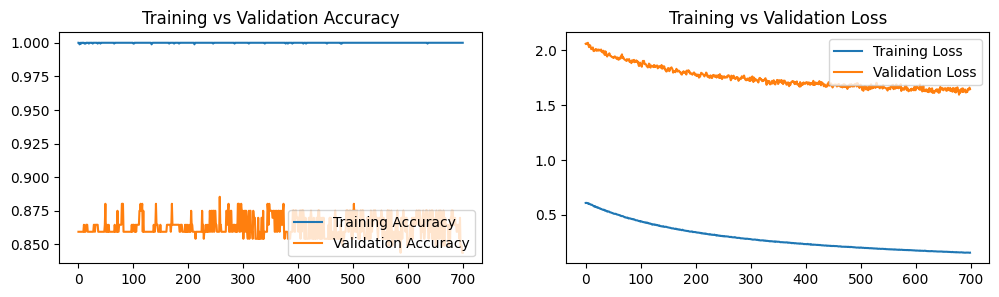

In [ ]:

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(len(loss)), loss, label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

In [ ]:
def prediction(audio_file):


    with open('/content/prediction.json', mode='r') as f:
        prediction_dict = json.load(f)


    audio, sample_rate =librosa.load(audio_file)


    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_features = np.mean(mfccs_features, axis=1)


    mfccs_features = np.expand_dims(mfccs_features, axis=0)
    mfccs_features = np.expand_dims(mfccs_features, axis=2)


    mfccs_tensors = tf.convert_to_tensor(mfccs_features, dtype=tf.float32)


    model = tf.keras.models.load_model('/content/model.h5')
    prediction = model.predict(mfccs_tensors)


    target_label = np.argmax(prediction)


    predicted_class = prediction_dict[str(target_label)]
    confidence = round(np.max(prediction)*100, 2)

    print(f'Predicted Class : {predicted_class}')
    print(f'Confidence : {confidence}%')

In [ ]:
prediction('/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan10.mp3')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Predicted Class : Ornate Tinamou_sound
Confidence : 18.469999313354492%


In [ ]:
prediction('/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Andean Tinamou_sound/Andean Tinamou10.mp3')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Predicted Class : Andean Tinamou_sound
Confidence : 19.540000915527344%


In [ ]:
prediction('/content/sound-of-114-species-of-birds-till-2022/Voice of Birds/Voice of Birds/Bearded Guan_sound/Bearded Guan10.mp3')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Predicted Class : Bearded Guan_sound
Confidence : 87.08999633789062%
